# Employee Attrition Analysis and Predictive Modeling

Analyzing employee turnover patterns using exploratory data analysis, statistical testing, and machine learning to identify drivers of attrition and support retention strategy decisions.

**Business Problem**

Employee attrition creates operational and financial challenges for organizations through increased hiring costs, productivity loss, and reduced team continuity.

This project analyzes workforce patterns associated with employee turnover and builds predictive models capable of identifying employees at elevated risk of leaving.

**Dataset Overview**

The dataset contains employee-level information related to workload, satisfaction, evaluation metrics, compensation, and turnover status.

Limitations include the absence of demographic variables, compensation detail granularity, and external labor market factors.

## Data Cleaning and Exploratory Data Analysis


In [1]:
import pickle

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

# Staistics
from scipy import stats

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import plot_tree


import warnings
warnings.filterwarnings('ignore')
# Lets us see all of the columns
pd.set_option('display.max_columns', None)

**Load Data**


In [2]:
# Load dataset into a dataframe
df_0 = pd.read_csv("HR_comma_sep.csv")

df_0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Basic Information**


In [3]:
df_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


There are a total of 14999 rows and 10 columns. We have a mixture of numeric (int64 or float64) and categorical variables. We also have no missing values, which is good news.

### Data Cleaning

The code below cleans the data and prepares it for the EDA process

In [4]:
# Rename columns as needed
df_0.rename(columns={"last_evaluation":"latest_evaluation_score",
                    "Work_accident":"work_accident", 
                    "number_project":"projects_contributed",
                    "Department":"department",
                    "time_spend_company":"tenure",
                   "average_montly_hours":"average_monthly_hours",
                   "promotion_last_5years":"promoted_in_last_5_years"
                   },
           inplace=True)
df_0.columns

Index(['satisfaction_level', 'latest_evaluation_score', 'projects_contributed',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promoted_in_last_5_years', 'department', 'salary'],
      dtype='object')

In [5]:
# Check for missing values
df_0.isna().sum()

satisfaction_level          0
latest_evaluation_score     0
projects_contributed        0
average_monthly_hours       0
tenure                      0
work_accident               0
left                        0
promoted_in_last_5_years    0
department                  0
salary                      0
dtype: int64

None of the data's columns contain missing values

In [6]:
# Checking for duplicates
print(f"There are {df_0.duplicated().sum()} duplicate rows in the dataset.")

There are 3008 duplicate rows in the dataset.


In [7]:
# Inspect some rows containing duplicates as needed

# Checking the first 1500 rows for duplicates and sorting by satisfaction level to make it easier to visualize
df_0.iloc[:1500,][df_0.iloc[:1500,].duplicated(keep=False)].sort_values("satisfaction_level")

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure,work_accident,left,promoted_in_last_5_years,department,salary
178,0.37,0.51,2,127,3,0,1,0,sales,medium
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
866,0.41,0.46,2,128,3,0,1,0,accounting,low
28,0.41,0.46,2,128,3,0,1,0,accounting,low
1292,0.41,0.52,2,132,3,0,1,0,RandD,low
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low
396,0.46,0.57,2,139,3,0,1,0,sales,low
23,0.46,0.57,2,139,3,0,1,0,sales,low


In [8]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df_0.drop_duplicates()

print(f"Removed {len(df_0)-len(df)} duplicate rows")

Removed 3008 duplicate rows


**Checking for Outliers**

The following code computes the mean, median, for our numerical, non-binary features. This summary allows us to inspect the data range and variance to identify potential outliers or anomalies that may require further investigation.

In [9]:
df_0[["satisfaction_level", "latest_evaluation_score", "projects_contributed", 
        "average_monthly_hours", "tenure"]].describe().loc[["mean","50%","min","25%","75%","max"],:]

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure
mean,0.612834,0.716102,3.803054,201.050337,3.498233
50%,0.640000,0.720000,4.000000,200.000000,3.000000
min,0.090000,0.360000,2.000000,96.000000,2.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000


There is a noticeable discrepancy between the mean and the median of `tenure`. We observe a substantial gap between the 75th percentile and the maximum value for this variable. Specifically, while the interquartile range (25th to 75th percentile) shows only a 1-point increase, there is a significant 6-point jump from the 75th percentile to the maximum. 

These observations strongly suggest the presence of high-value outliers in the `tenure` variable. The code below creates a boxplot to visualize and confirm this

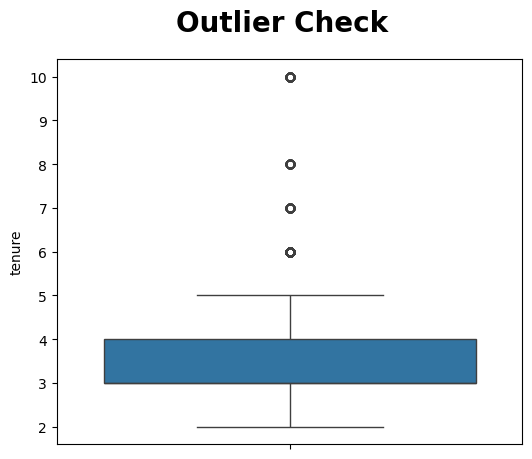

In [10]:
# boxplot  visualization of the  distribution of `tenure` to detect any outliers

fig, axes = plt.subplots(figsize=(6,5))
sns.boxplot(y=df["tenure"])
fig.suptitle("Outlier Check", fontsize=20, fontweight='bold')
plt.show()

The code below checks for mathematical outliers(values larger than 1.5*IQR), we will only check for values greater than the upper bound since we did not observe any outliers beyond the 1st quartile

In [11]:

percentile25 = df['tenure'].quantile(0.25)

percentile75 = df['tenure'].quantile(0.75)

iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
outlier_rows = df[df["tenure"] > upper_limit].shape[0]

print("{} rows are outliers as they have a tenure higher than {} years".format(outlier_rows,upper_limit))
print("This is {}% of the total number of rows in the dataset".format(round(outlier_rows/df.shape[0]*100,2)))

824 rows are outliers as they have a tenure higher than 5.5 years
This is 6.87% of the total number of rows in the dataset


Since only 6.87% of total rows are outliers, we will keep them in the dataset for analysis as they may provide useful information about employees with very high tenure. 
However, we will revisit this decision after we have done some more analysis on the dataset to see if these outliers need to be accounted for in our modeling.

## Exploratory Data Analysis

This section examines attrition patterns across satisfaction, workload, evaluation, tenure, promotion history, department, and salary.

In [12]:
# Gather descriptive statistics about the data
df.describe(include='all')

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure,work_accident,left,promoted_in_last_5_years,department,salary
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991,11991
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3239,5740
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929,NaN,NaN
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Descriptive Statistics: Key Observations

- Average satisfaction score: 0.63.
- Average evaluation score: 0.72.
- Average monthly hours: 200, ranging from 96 to 310 hours.
- Average tenure: 3.36 years.
- 16.6% of employees left.
- Only 2.1% of employees were promoted in the last 5 years.
- Sales is the largest department, and low salary is the most common salary level.

### Target Variable Distribution

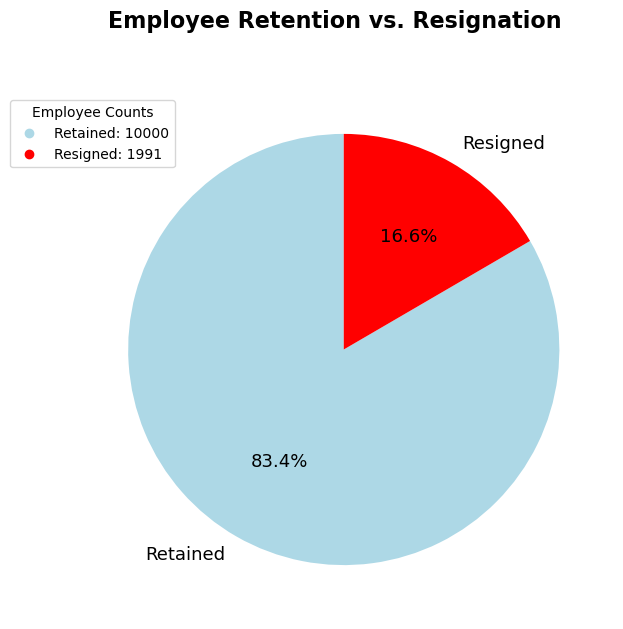

In [13]:
#plot a piechart to visualize the distribution of the target variable `left`
fig, axes = plt.subplots(figsize=(7,7))

labels = ["Retained", "Resigned"]
counts= df["left"].value_counts()

axes.pie(counts, 
         labels=labels, 
         autopct='%1.1f%%', 
         colors=['lightblue', 'red'], 
         startangle=90,
         textprops={'fontsize': 13}
         )

legend_labels = [f"{label}: {count}" for label, count in zip(labels, counts)]
legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='None') for color in ['lightblue', 'red']]

plt.legend(legend_handles, 
           legend_labels, 
           title="Employee Counts",
           loc="center right", 
           bbox_to_anchor=(0.2, 0.9)
           )

fig.suptitle("Employee Retention vs. Resignation", fontsize=16, fontweight="bold")
plt.show()

- 83.4% of employees were retained.
- 16.6% of employees resigned.
- Because the target variable is imbalanced, F1 score will be more useful than accuracy during model evaluation.

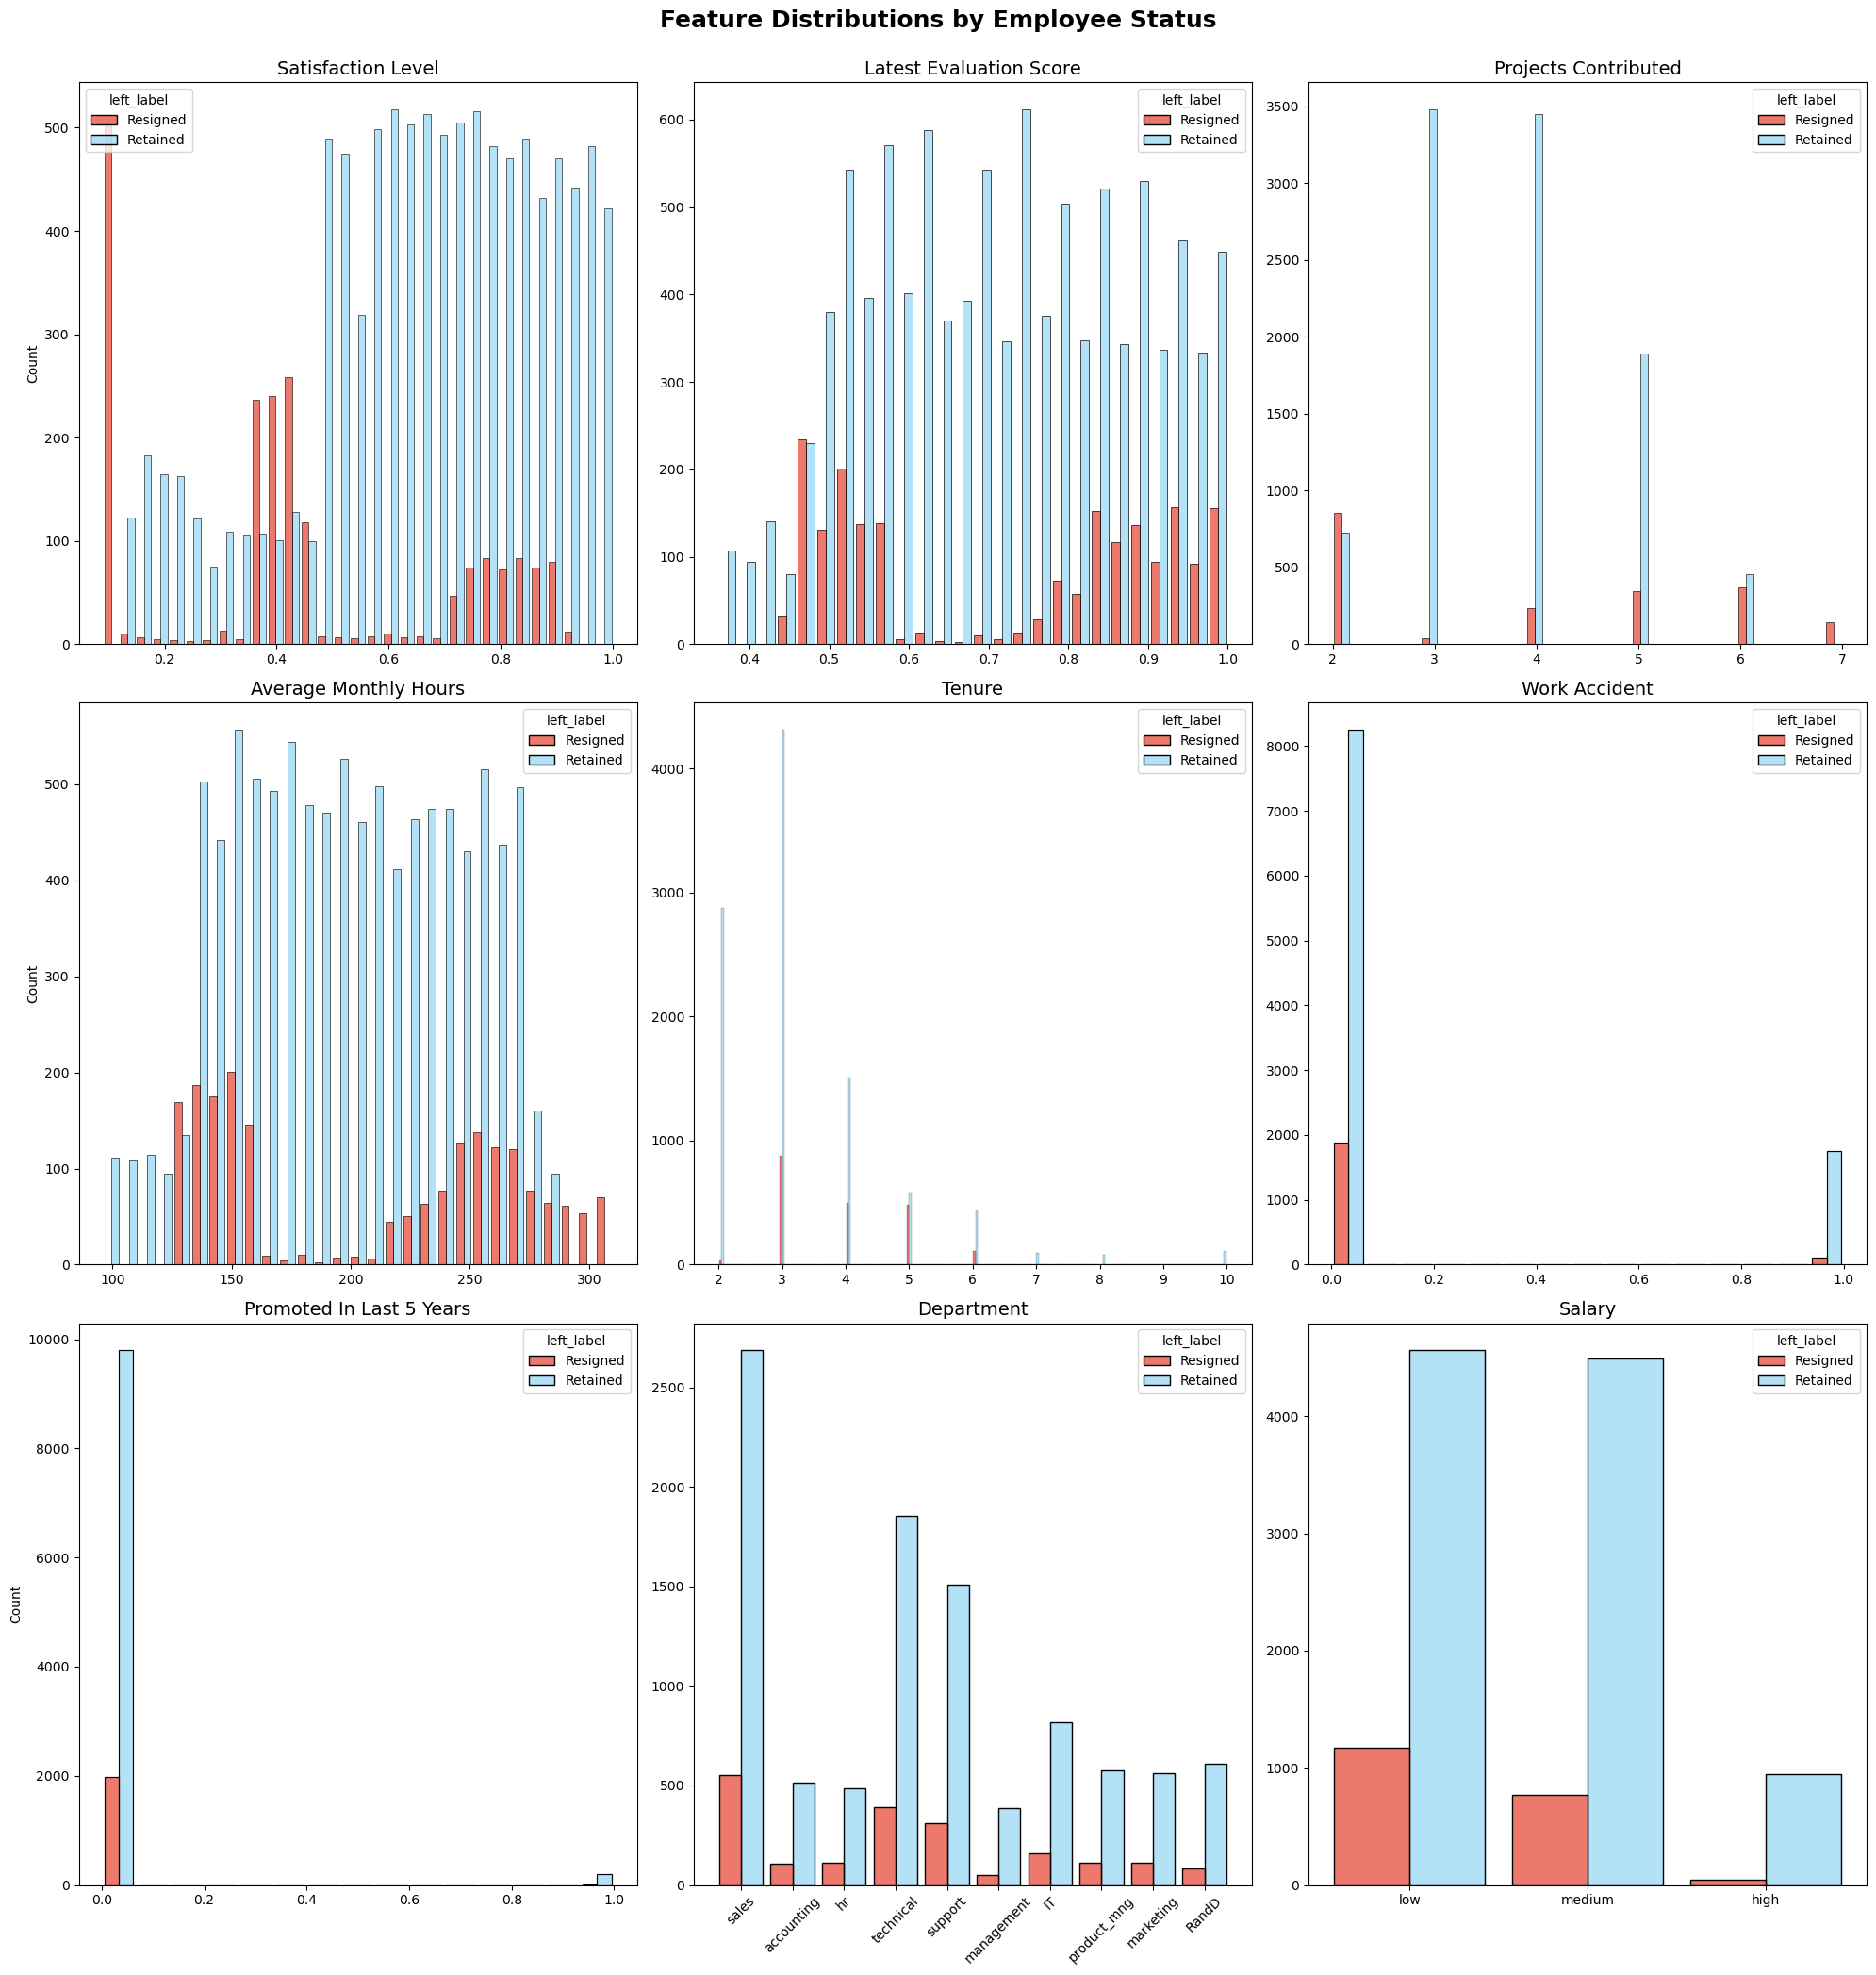

In [14]:
retained_color = "#9AD7F3"  
resigned_color = "#E74C3C"   
palette = {"Retained": retained_color, "Resigned": resigned_color}
colors = [retained_color, resigned_color]

df_plot = df.copy()
df_plot["left_label"] = df_plot["left"].map({0: "Retained", 1: "Resigned"})

fig, axes = plt.subplots(3, 3, figsize=(20, 22))
axes = axes.flatten()

for a, col in enumerate(df.columns.drop("left")):
    sns.histplot(
        data=df_plot,
        x=col,
        hue="left_label",
        multiple="dodge",
        shrink=0.85,
        palette=palette,
        ax=axes[a]
    )
    axes[a].set_title(col.replace("_", " ").title(), fontsize=14)
    axes[a].set_ylabel("Count" if a % 3 == 0 else "")
    axes[a].set_xlabel("")

for tick in axes[7].get_xticklabels():
    tick.set_rotation(45)

fig.suptitle("Feature Distributions by Employee Status", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Distribution Observations

- Resigned employees show lower satisfaction levels overall.
- Attrition is concentrated among employees with either very low workload/project levels or very high workload/project levels.
- Employees with 6–7 projects show elevated resignation patterns.
- Resignations are most concentrated around 3–5 years of tenure.
- Promotion rates are low across the dataset, especially for employees who left.

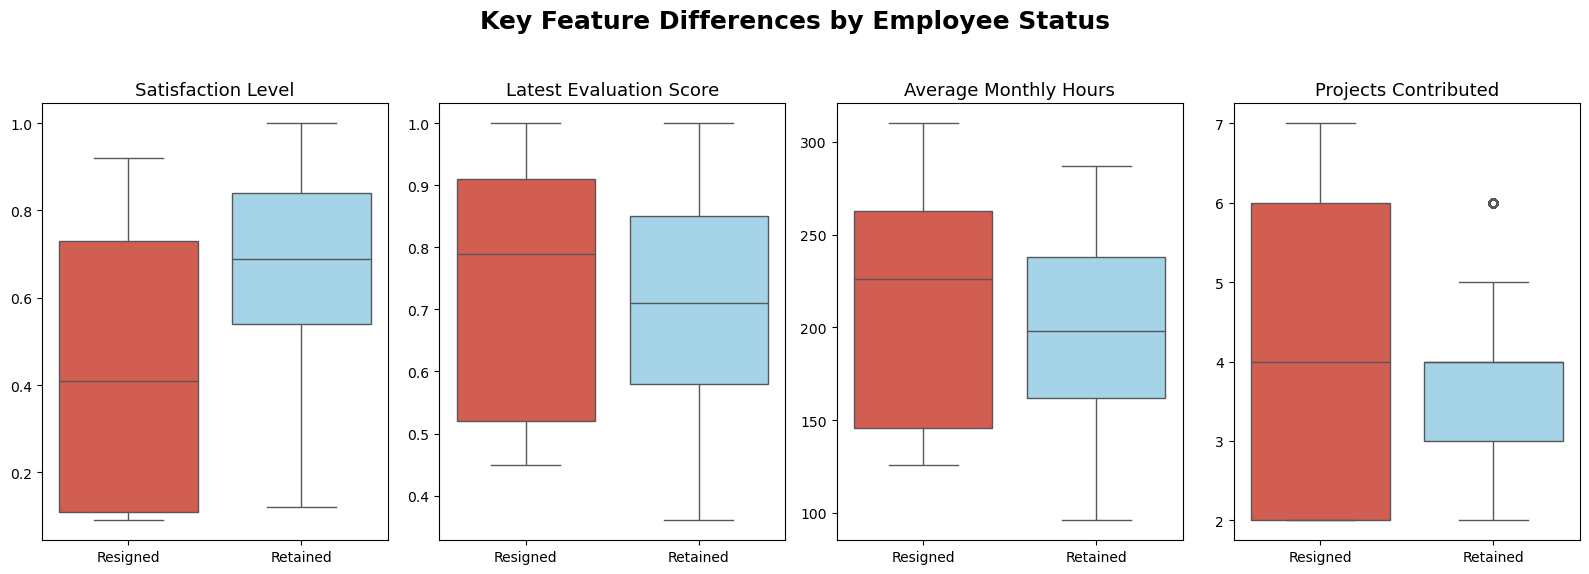

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

features = [
    "satisfaction_level",
    "latest_evaluation_score",
    "average_monthly_hours",
    "projects_contributed"
]

for a, col in enumerate(features):
    sns.boxplot(
        data=df_plot,
        x="left_label",
        y=col,
        palette=palette,
        ax=axes[a]
    )
    axes[a].set_title(col.replace("_", " ").title(), fontsize=13)
    axes[a].set_xlabel("")
    axes[a].set_ylabel("")

fig.suptitle("Key Feature Differences by Employee Status", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Boxplot Observations

- Employees who resigned had lower median satisfaction.
- Resigned employees generally worked more hours and contributed to more projects.
- Evaluation scores were often higher among employees who left, suggesting that attrition includes high-performing employees.
- The resignation group shows wider variation, indicating multiple attrition profiles rather than one uniform pattern.

#### Variable Relationships

In this section we will move from univariate analysis (looking at one variable) to bivariate and multivariate analysis. We will explore the interrelationships between features to identify patterns that contribute to attrition. Understanding how variables correlate and interact is essential for determining the key drivers of employee departure. 

We will begin by analyzing how retention patterns shift as we examine the interaction between pairs of variables.

The code below creates a custom function to create a scatter plot between two variables

In [16]:
def scatterplt(x, y, a):
    sns.scatterplot(
        data=df[df["left"] == 0],
        x=x,
        y=y,
        color=retained_color,
        alpha=0.18,
        ax=axes[a],
        label="Retained"
    )
    
    sns.scatterplot(
        data=df[df["left"] == 1],
        x=x,
        y=y,
        color=resigned_color,
        alpha=0.75,
        ax=axes[a],
        label="Resigned"
    )
    
    axes[a].set_title(f"{y.replace('_',' ').title()} vs. {x.replace('_',' ').title()}", fontsize=13)
    axes[a].set_xlabel(x.replace("_", " ").title())
    axes[a].set_ylabel(y.replace("_", " ").title())

### Satisfaction Patterns by Workload and Performance

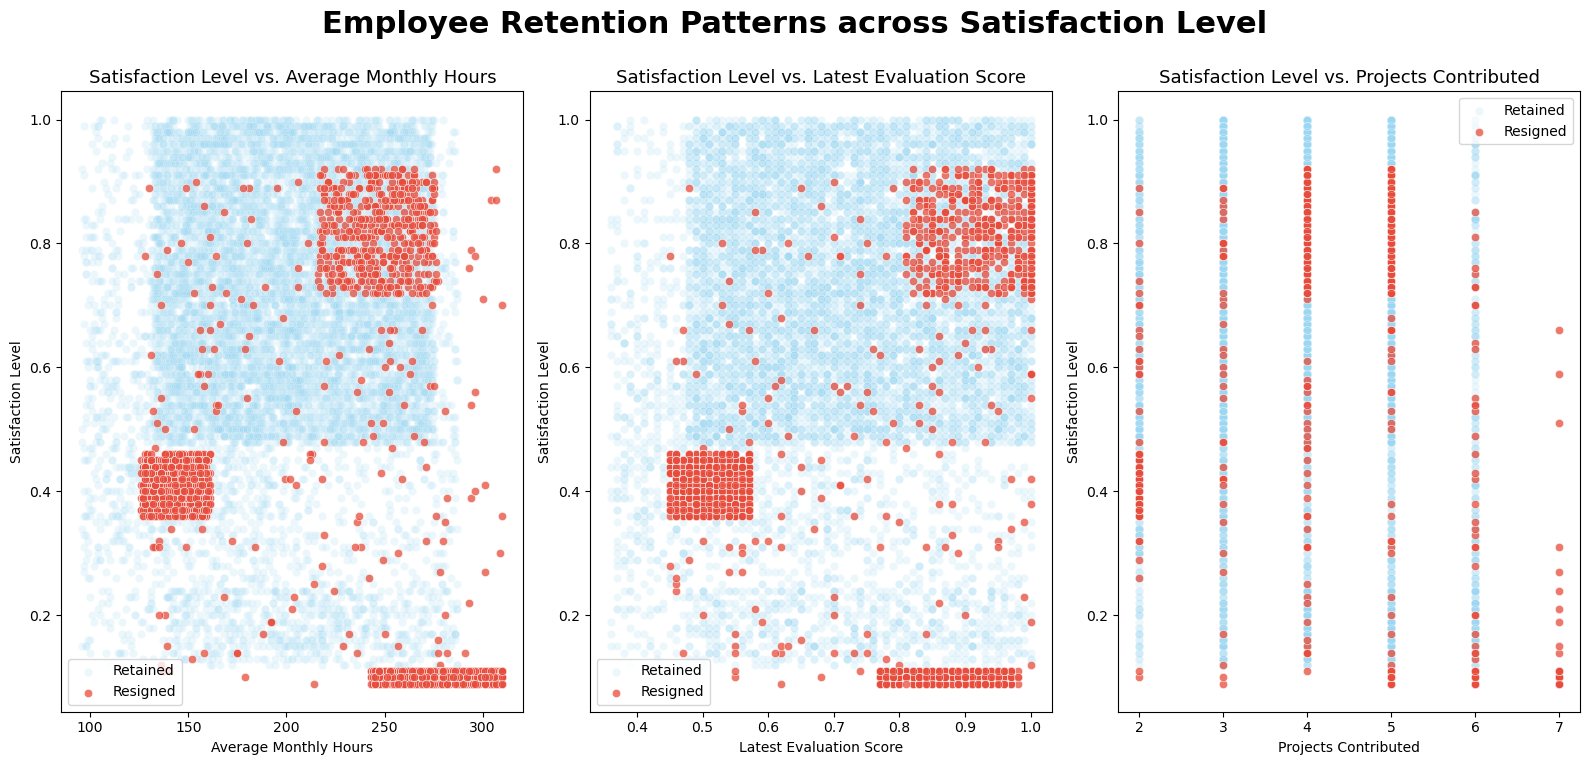

In [17]:
fig, axes = plt.subplots(1,3,figsize=(16,8))
axes = axes.flatten()

scatterplt("average_monthly_hours","satisfaction_level",0)
scatterplt("latest_evaluation_score","satisfaction_level",1)
scatterplt("projects_contributed","satisfaction_level",2)

fig.suptitle("Employee Retention Patterns across Satisfaction Level",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Satisfaction Scatterplot Observations

- Resigned employees cluster at very low satisfaction levels.
- High monthly hours combined with low satisfaction is strongly associated with resignation.
- Employees with high evaluation scores and high workloads also show resignation risk.
- Employees assigned 6–7 projects appear especially vulnerable to attrition.

### Department-Level Attrition

Technical and workload-intensive departments show the highest attrition rates, suggesting that operational pressure may differ across organizational units.

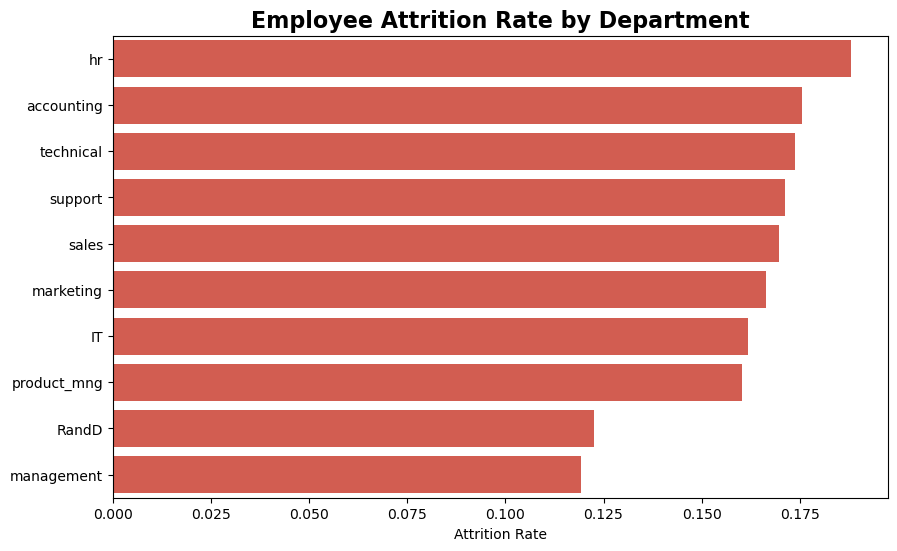

In [18]:
dept_attrition = (
    df.groupby("department")["left"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=dept_attrition,
    x="left",
    y="department",
    color=resigned_color
)

plt.xlabel("Attrition Rate")
plt.ylabel("")
plt.title("Employee Attrition Rate by Department", fontsize=16, fontweight="bold")

plt.show()

HR, Accounting, and Technical departments show the highest attrition rates, while Management and R&D exhibit the lowest.

This suggests workload demands and organizational structure may influence retention differently across departments.

### Evaluation Score, Workload, and Attrition

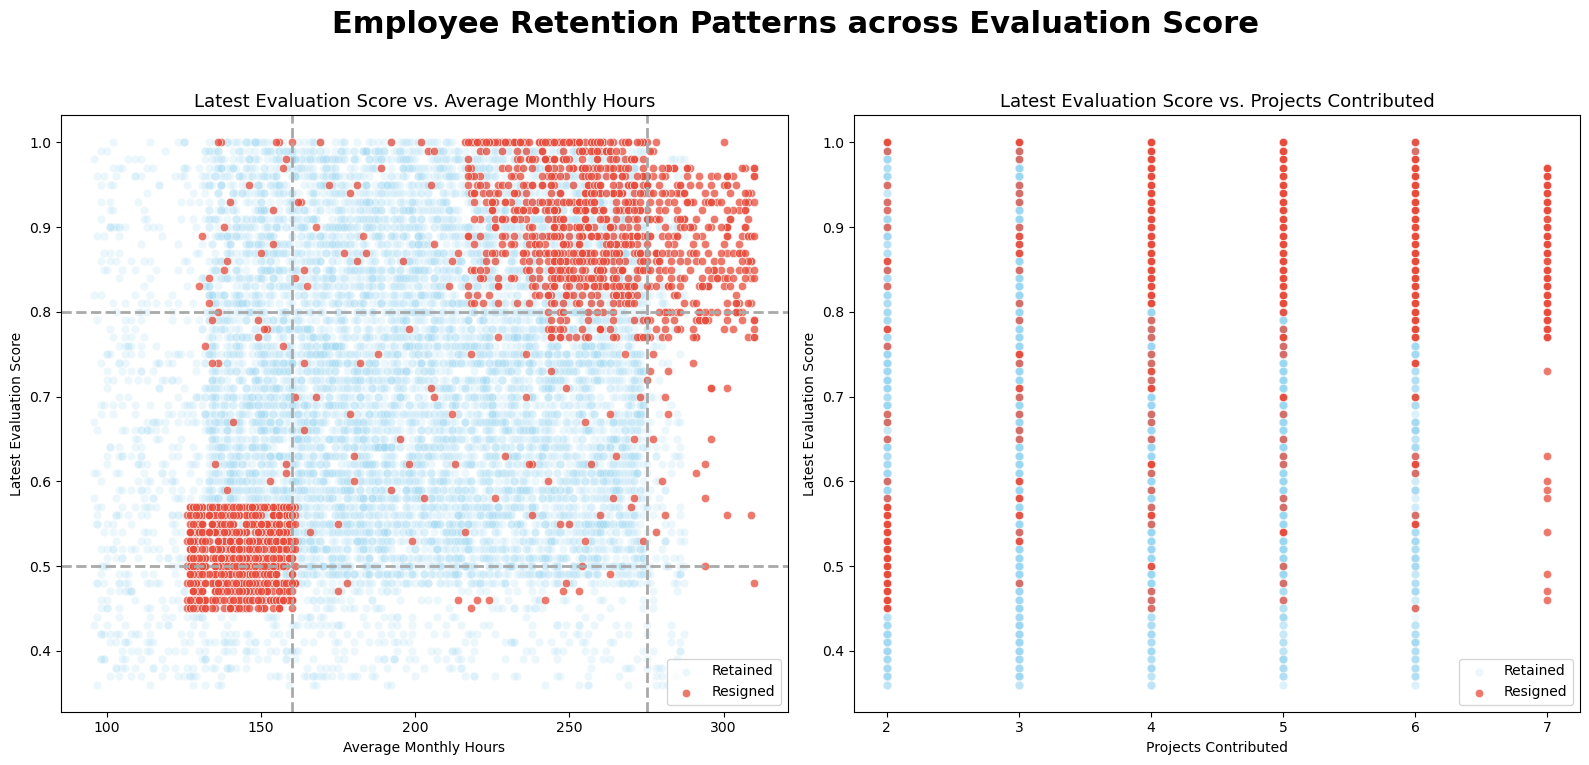

In [19]:
fig, axes = plt.subplots(1,2,figsize=(16,8))

scatterplt("average_monthly_hours","latest_evaluation_score",0)
scatterplt("projects_contributed","latest_evaluation_score",1)

fig.suptitle("Employee Retention Patterns across Evaluation Score",fontsize=22, fontweight='bold')

axes[0].axhline(y=0.8, color='darkgray', linestyle='--', linewidth=2)
axes[0].axhline(y=0.5, color='darkgray', linestyle='--', linewidth=2)
axes[0].axvline(x=160, color='darkgray', linestyle='--', linewidth=2)
axes[0].axvline(x=275, color='darkgray', linestyle='--', linewidth=2)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Evaluation Scatterplot Observations

- Resigned employees form clear clusters rather than appearing randomly distributed.
- One group shows low hours, low evaluation scores, and low project counts.
- Another group shows high evaluation scores, high project counts, and high monthly hours.
- The 160–220 monthly hour range with 3–5 projects appears more stable for retention.

### Average Metrics by Tenure

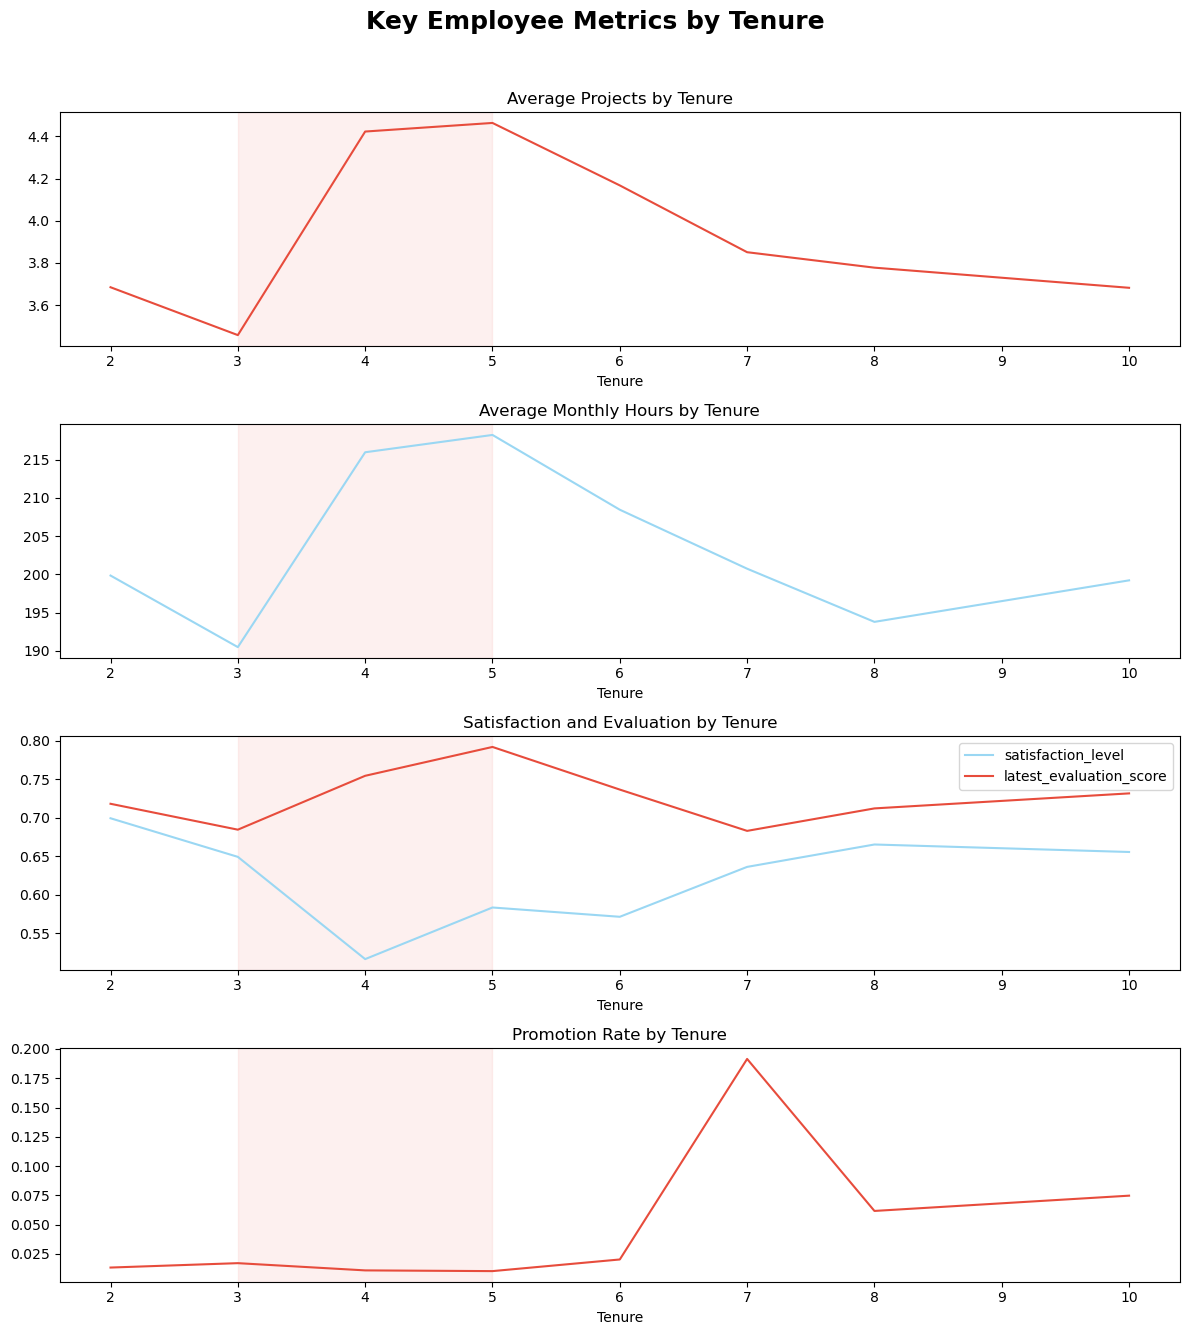

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14))

tenure_bd = df.groupby("tenure").mean(numeric_only=True)

tenure_bd[["projects_contributed"]].plot(ax=axes[0], color=resigned_color, legend=False)
axes[0].set_title("Average Projects by Tenure")

tenure_bd[["average_monthly_hours"]].plot(ax=axes[1], color=retained_color, legend=False)
axes[1].set_title("Average Monthly Hours by Tenure")

tenure_bd[["satisfaction_level", "latest_evaluation_score"]].plot(
    ax=axes[2],
    color=[retained_color, resigned_color]
)
axes[2].set_title("Satisfaction and Evaluation by Tenure")

tenure_bd[["promoted_in_last_5_years"]].plot(ax=axes[3], color=resigned_color, legend=False)
axes[3].set_title("Promotion Rate by Tenure")

for ax in axes:
    ax.axvspan(3, 5, color=resigned_color, alpha=0.08)
    ax.set_xlabel("Tenure")

fig.suptitle("Key Employee Metrics by Tenure", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Tenure-Based Observations

- Years 3–5 appear to be the highest-risk tenure window.
- Workload and project count rise during this period.
- Satisfaction reaches its lowest point around year 4.
- Promotions remain rare during the same period.
- This suggests attrition risk may increase when workload rises without visible advancement.

### Retention Patterns Across Tenure

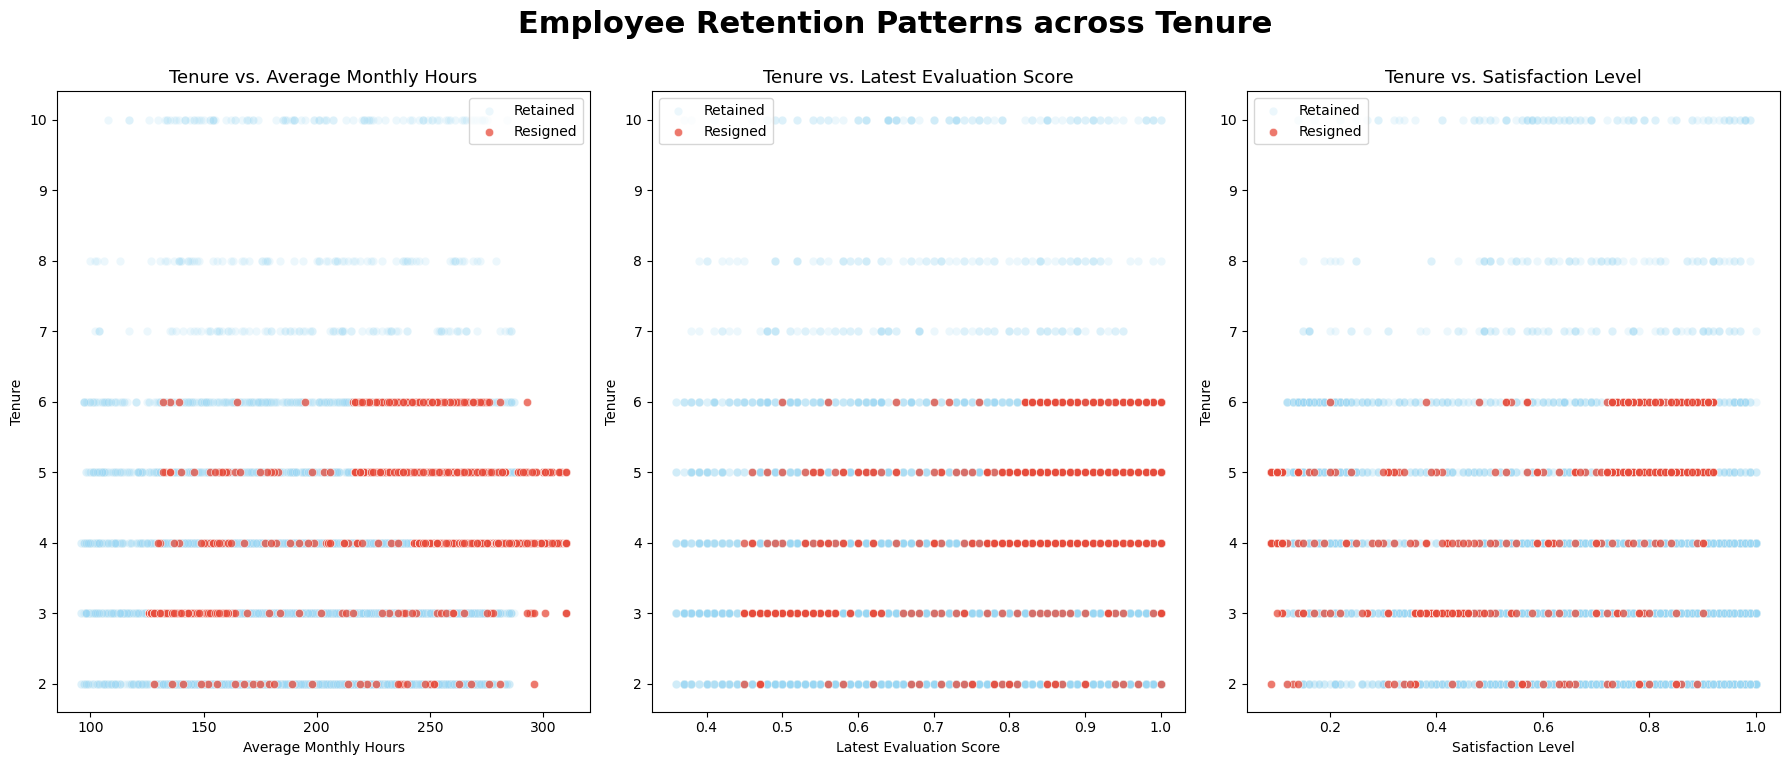

In [21]:
fig, axes = plt.subplots(1,3,figsize=(18,8))

axes = axes.flatten()

scatterplt("average_monthly_hours","tenure",0)
scatterplt("latest_evaluation_score","tenure",1)
scatterplt("satisfaction_level","tenure",2)

fig.suptitle("Employee Retention Patterns across Tenure",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Tenure Scatterplot Observations

- Attrition is concentrated between 3 and 5 years of tenure.
- Employees with 7+ years rarely leave in this dataset.
- Mid-tenure employees show both burnout-style and disengagement-style resignation patterns.
- The 3–5 year range should be treated as the main retention intervention window.

### Hypothesis Test: Mid-Tenure Satisfaction

This test compares satisfaction levels for employees in the 3–5 year tenure window against all other employees.

- $H_0$: Mid-tenure employees have equal or higher satisfaction.
- $H_A$: Mid-tenure employees have lower satisfaction.

In [22]:
# creating a seperate variable for those in the critical retention period of 3-5 years to compare with those outside of that period.
df['mid_tenure'] = np.where((df['tenure'] >= 3) & (df['tenure'] <= 5),1,0)

# Isolating the `satisfaction_level` column for mid-tenure employees.
mid_tenure = df[(df['mid_tenure'] == 1)]['satisfaction_level']

# Isolating the `satisfaction_level` column for employees outside the mid-tenure period.
not_mid_tenure = df[(df['mid_tenure'] == 0)]['satisfaction_level']

# One-sided Welch's t-test
two_sample= stats.ttest_ind(a=mid_tenure, b=not_mid_tenure, equal_var=False, alternative='less')
print(f"Results of Two-sample t-test\n \nT-stat: {two_sample[0]} \nP-value: {two_sample[1]}")

Results of Two-sample t-test
 
T-stat: -15.631955199332081 
P-value: 1.2368179888174391e-54


The Welch’s t-test shows that mid-tenure employees have significantly lower satisfaction than employees outside the 3–5 year range.

This supports the earlier visual finding that years 3–5 represent a critical attrition-risk period.

### Mid-Tenure Resignation Rate

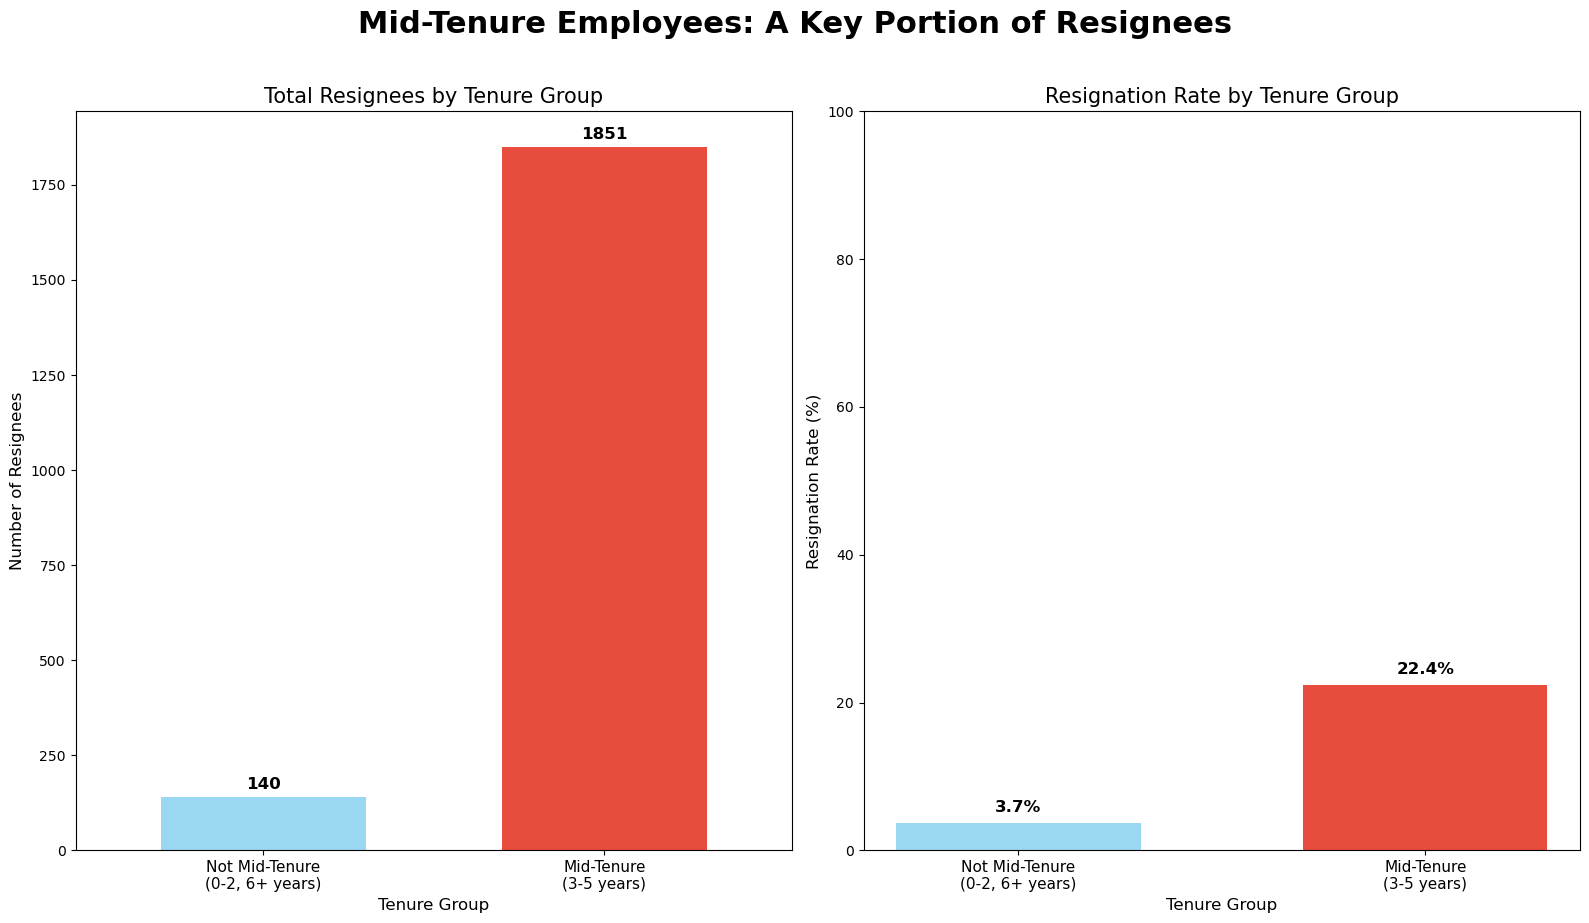

Mid-Tenure Employee Resignation Analysis
Mid-Tenure Resignees (3-5 years): 1851 out of a total of 8257 mid-tenure employees (22.4%)
Other Resignees: 140 out of a total of 3734 other employees (3.7%)

Mid-tenure employees represent 93.0% of all resignees


In [23]:

# Calculate resignation rates by mid-tenure status
mid_tenure_analysis = df.groupby('mid_tenure')['left'].agg(['sum', 'count'])
mid_tenure_analysis['resignation_rate'] = mid_tenure_analysis['sum'] / mid_tenure_analysis['count']
mid_tenure_analysis.index = ['Not Mid-Tenure (0-2, 6+ years)', 'Mid-Tenure (3-5 years)']

# visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Plot 1: Resignation counts
colors = [retained_color, resigned_color]
mid_tenure_analysis['sum'].plot(kind='bar', ax=axes[0], color=colors, width=0.6)
axes[0].set_title('Total Resignees by Tenure Group', fontsize=15)
axes[0].set_ylabel('Number of Resignees', fontsize=12)
axes[0].set_xlabel('Tenure Group', fontsize=12)
axes[0].set_xticklabels(['Not Mid-Tenure\n(0-2, 6+ years)', 'Mid-Tenure\n(3-5 years)'], fontsize=11, rotation=360,ha='center')
for i, v in enumerate(mid_tenure_analysis['sum']):
    axes[0].text(i, v + 20, str(int(v)), ha='center', fontsize=12, fontweight='bold')

# Plot 2: Resignation rate (%)
resignation_pct = (mid_tenure_analysis['resignation_rate'] * 100)
bars = axes[1].bar(range(len(resignation_pct)), resignation_pct, color=colors, width=0.6)
axes[1].set_title('Resignation Rate by Tenure Group', fontsize=15)
axes[1].set_ylabel('Resignation Rate (%)', fontsize=12)
axes[1].set_xlabel('Tenure Group', fontsize=12)
axes[1].set_xticks(range(len(resignation_pct)))
axes[1].set_xticklabels(['Not Mid-Tenure\n(0-2, 6+ years)', 'Mid-Tenure\n(3-5 years)'], fontsize=11)
axes[1].set_ylim(0, 100)
for i, (bar, v) in enumerate(zip(bars, resignation_pct)):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

fig.suptitle('Mid-Tenure Employees: A Key Portion of Resignees', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("Mid-Tenure Employee Resignation Analysis")
print("=" * 60)
print(f"Mid-Tenure Resignees (3-5 years): {int(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'sum'])} out of a total of {int(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'count'])} mid-tenure employees ({resignation_pct.iloc[1]:.1f}%)")
print(f"Other Resignees: {int(mid_tenure_analysis.loc['Not Mid-Tenure (0-2, 6+ years)', 'sum'])} out of a total of {int(mid_tenure_analysis.loc['Not Mid-Tenure (0-2, 6+ years)', 'count'])} other employees ({resignation_pct.iloc[0]:.1f}%)")
print(f"\nMid-tenure employees represent {(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'sum'] / mid_tenure_analysis['sum'].sum() * 100):.1f}% of all resignees")

- Mid-tenure employees have a higher resignation rate than employees outside the 3–5 year range.
- This group represents a major share of total resignations.
- Retention strategies should focus on employees before and during this tenure window.

## EDA Summary

- 16.6% of employees resigned.
- Resigned employees generally had lower satisfaction, higher workloads, and more project assignments.
- Attrition is concentrated around years 3–5 of tenure.
- Employees with very high workloads and strong evaluations appear to represent a high-performing attrition-risk group.
- Employees with low workload, low satisfaction, and low evaluation scores represent a second disengaged attrition-risk group.
- Promotions are rare, suggesting limited advancement may contribute to turnover risk.
- These findings support adding a `mid_tenure` feature for modeling.

# Model Building and Evaluation 

This section builds classification models to predict employee attrition using workload, performance, tenure, promotion, salary, and department-related features. Models are evaluated using precision, recall, F1 score, and accuracy, with F1 score emphasized because the target variable is imbalanced.

### Feature Preparation 

The modeling dataset was copied from the cleaned dataframe. Salary was ordinally encoded, department was one-hot encoded, and the original tenure variable was removed after creating the `mid_tenure` feature.

In [24]:
df_model = df.copy()
# Label encode the `salary` column as an ordinal numeric category
df_model['salary'] = df['salary'].astype('category').cat.set_categories(['low', 'medium', 'high']).cat.codes
# Dummy encode the `department` column
df_model = pd.get_dummies(df_model, drop_first=False)
# Drop the original tenure variable to avoid multicollinearity
df_model.drop(columns="tenure", inplace=True)

df.to_csv("employee_attrition_cleaned.csv", index=False) # clean data to use for tableau dashboard

### Part A: Logistic Regression


**Logistic Regression model assumptions** 

We will first check if our data meets the Logistic Regression model assumptions.
5 of these will be checked for now. i.e. before constructing the model and the last of these will be checked post construction.

**Pre Construction (Assumptions 1-5)**

* The outcome variable is categorical as we predict on whether an employee resigned or not
* As each observation refers to an independent employee, therefore we can assume that they are independent of each other
* Since we have dropped the tenure variable, therefore we no longer have extreme outliers in our dataset
* Given that $n \approx 15,000$, we have an adequate sample size to satisfy the assumptions required for most predictive modeling and statistical tests


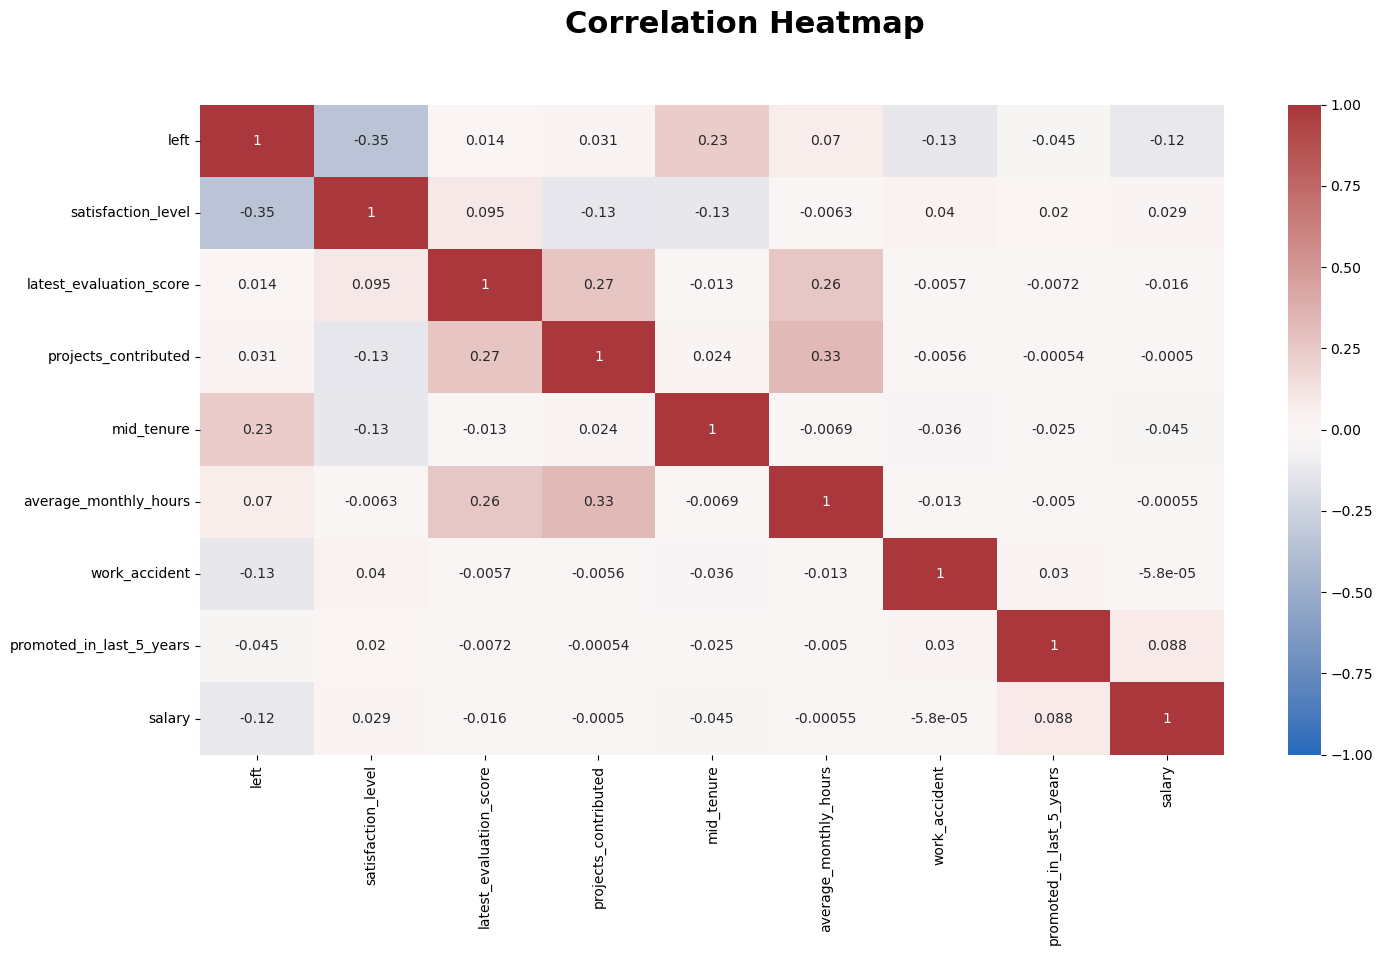

In [25]:
# Check correlation among predictors

fig, axes = plt.subplots(figsize=(15,10))

sns.heatmap(df_model[['left','satisfaction_level', 'latest_evaluation_score', 'projects_contributed', 'mid_tenure', 'average_monthly_hours',
                    'work_accident', 'promoted_in_last_5_years','salary']].corr(), vmin=-1, vmax=1,
            annot=True,cmap = sns.color_palette("vlag", as_cmap=True))
fig.suptitle('Correlation Heatmap',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show();

The correlation heatmap shows no severe multicollinearity among the selected predictors. The strongest relationships with attrition appear around satisfaction level, evaluation score, project count, monthly hours, and the engineered `mid_tenure` variable.

### Train/Test Split

Data was divided into training and testing sets to evaluate model generalization on unseen employee records.

In [26]:
# Save X and y data into variables
X_log = df_model.drop(columns='left')
y_log = df_model["left"]

#stratify = y as classes are imbalanced
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, stratify=y_log, test_size=0.25, random_state=16)

# Build regression model
clf = LogisticRegression(class_weight='balanced', max_iter=500)
clf.fit(X_train_log,y_train_log)

LogisticRegression(class_weight='balanced', max_iter=500)

### Logistic Regression Assumption Check 

The logit relationship was checked for key numerical predictors before fitting the logistic regression model.

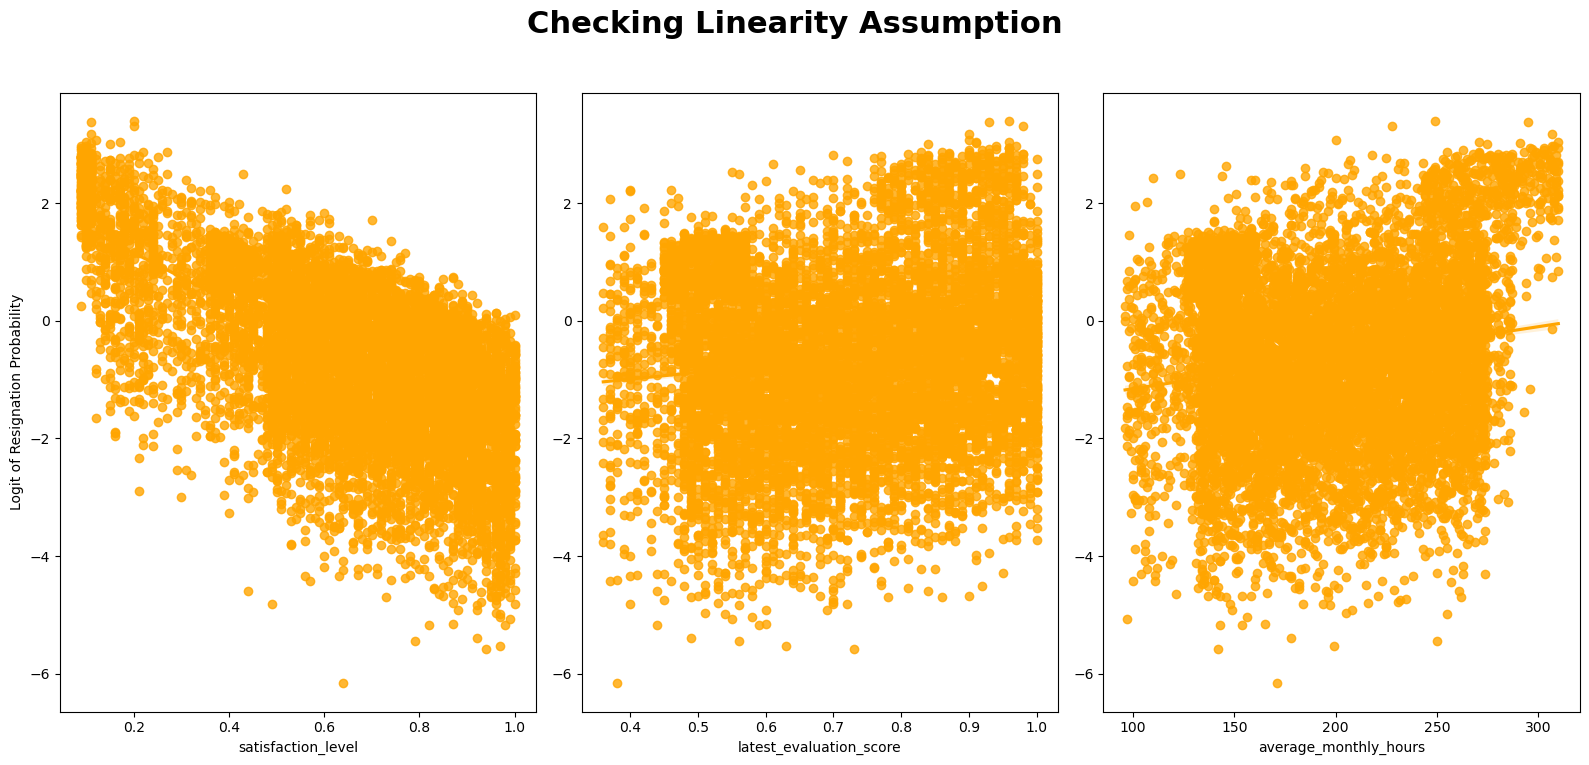

In [27]:
## Checking Linearity assumption

training_probabilities = clf.predict_proba(X_train_log)
training_probabilities


logit_data = X_train_log


logit_data["logit"] = [np.log(prob[1]/prob[0]) for prob in training_probabilities]

fig, axes = plt.subplots(1,3,figsize=(16,8))


axes = axes.flatten()


a= 0
for i in ["satisfaction_level","latest_evaluation_score","average_monthly_hours"]:
    sns.regplot(x = str(i), y = "logit", data = logit_data, ax=axes[a], color='orange')
    axes[a].set_ylabel("") 
    a += 1

axes[0].set_ylabel("Logit of Resignation Probability")
fig.suptitle('Checking Linearity Assumption',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show();

The logit plot suggests that satisfaction level has a reasonably linear relationship with resignation probability, supporting its use in the logistic regression model.

In [28]:
# Check model coefficients to understand directionality of relationships
coef_df = pd.DataFrame({
    'Feature': X_train_log.columns.drop("logit"),
    'Coefficient': clf.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
coef_df.reset_index(drop=True).head(3)

,Feature,Coefficient
0,satisfaction_level,-3.867045
1,latest_evaluation_score,1.769128
2,mid_tenure,1.705049


The largest logistic regression coefficients were:

- `satisfaction_level`: -3.87
- `latest_evaluation_score`: 1.77
- `mid_tenure`: 1.71

Lower satisfaction is strongly associated with resignation, while higher evaluation scores and mid-tenure status increase predicted attrition risk.

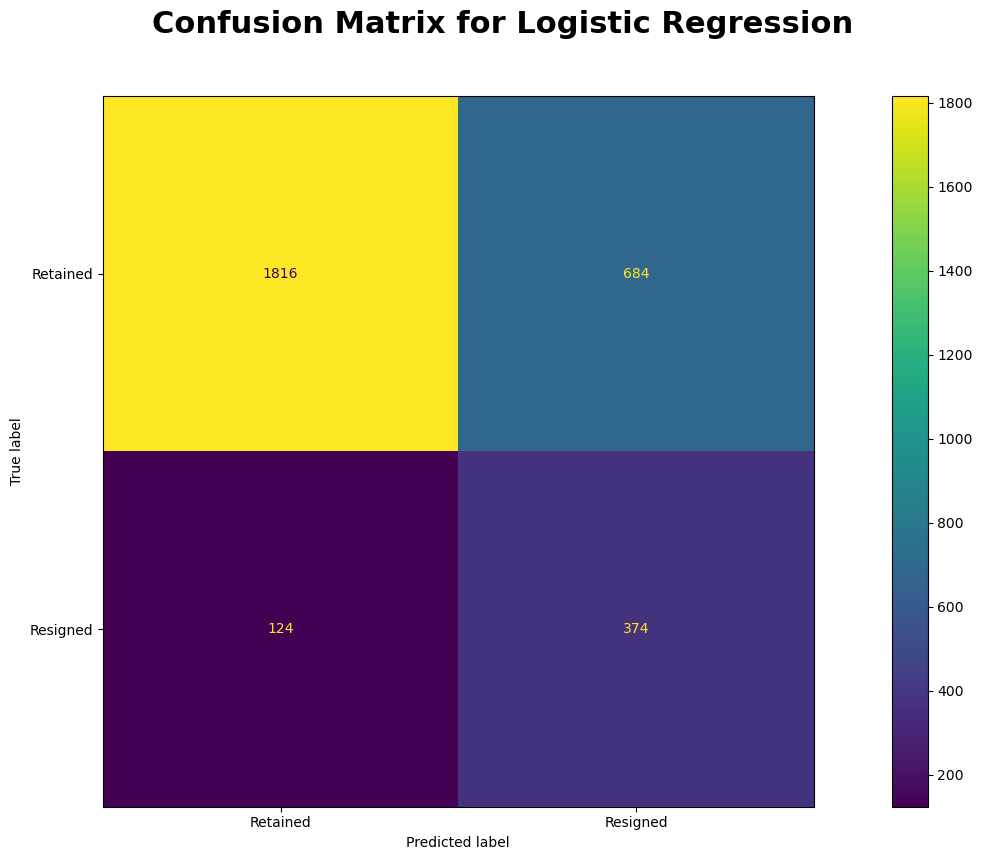

In [29]:
# Use the logistic regression model to get predictions on the test set
y_pred_log = clf.predict(X_test_log)

# Confusion matrix
cm = confusion_matrix(y_test_log, y_pred_log, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["Retained","Resigned"])

fig, ax = plt.subplots(figsize=(16, 9))
disp.plot(ax=ax)
fig.suptitle("Confusion Matrix for Logistic Regression", fontsize=22, fontweight='bold', x=0.6, horizontalalignment='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The confusion matrix shows how many employees were correctly or incorrectly classified as retained or resigned.

In [30]:
# Get accuracy scores
log_precision = precision_score(y_test_log,y_pred_log)
log_accuracy = accuracy_score(y_test_log,y_pred_log)
log_recall = recall_score(y_test_log,y_pred_log)
log_f1 = f1_score(y_test_log,y_pred_log)

# Create a dataframe to store the results for the logistic regression model
results = pd.DataFrame()
results = pd.DataFrame({'model': 'Logistic_Regression',
                          'precision': log_precision,
                          'recall':log_recall,
                          'F1': log_f1,
                          'accuracy': log_accuracy}, index=range(0,1))
results

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.353497,0.751004,0.48072,0.730487


The Logistic Regression model produced: - Accuracy: 73.0% - Precision: 0.35 - Recall: 0.75 - F1 score: 0.48 The model captured many resignations, but its low precision indicates many false positives. This makes it useful as a baseline but insufficient as the final model.

### Machine Learning Models: Random Forest and XGBoost

Random Forest and XGBoost were tested to capture non-linear relationships between workload, performance, tenure, and attrition.

In [31]:
#X = df_model.drop(columns='left')
X = df_model.drop(columns=['left','satisfaction_level'])
y = df_model["left"]

# Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=16)

# Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,
                                                  test_size=0.25, random_state=16)

### Random Forest Model Tuning

GridSearchCV was used to tune the Random Forest model using F1 score as the primary selection metric.

In [ ]:

%%time
rf = RandomForestClassifier(random_state=16)

cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 0.9],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate GridSearch
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')
rf_cv.fit(X_train, y_train)

In [32]:
from pathlib import Path
import joblib

BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "models"

rf_model = joblib.load(MODELS_DIR / "random_forest_model.pkl")
xgb_model = joblib.load(MODELS_DIR / "xgboost_model.pkl")
champion = joblib.load(MODELS_DIR / "champion_xgboost_model.pkl")

In [ ]:

rf_model_path = MODELS_DIR / "random_forest_model.pkl"
joblib.dump(rf_cv.best_estimator_, rf_model_path)

The Random Forest GridSearchCV results identify the best F1 score and hyperparameter combination.

In [ ]:
# print("Best F1 Score from GridSearchCV: ", rf_cv.best_score_)
# print("Best Parameters from GridSearchCV: ","\n", rf_cv.best_params_)

In [33]:
print("Best F1 Score from GridSearchCV: 0.8281174334727299")

print("Best Parameters from GridSearchCV:")
print({
    "max_depth": None,
    "max_features": 1.0,
    "max_samples": 0.7,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "n_estimators": 500
})

Best F1 Score from GridSearchCV: 0.8281174334727299
Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}


The best Random Forest model achieved a cross-validated F1 score of 0.828. Best parameters: - `max_depth`: None - `max_features`: 1.0 - `max_samples`: 0.7 - `min_samples_leaf`: 2 - `min_samples_split`: 2 - `n_estimators`: 500

In [34]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

The `make_results()` function extracts precision, recall, F1 score, and accuracy from the best cross-validated model.

In [ ]:
#results_rf_cv = make_results('Random Forest CV', rf_cv, 'f1')

#results = pd.concat([results, results_rf_cv], axis=0)
#results.reset_index(drop=True)

Random Forest substantially improved performance compared to Logistic Regression. The model achieved: - Precision: 0.876 - Recall: 0.786 - F1 score: 0.828 - Accuracy: 94.6% This suggests attrition patterns are better captured by non-linear models.

In [ ]:
%%time

xgb = XGBClassifier(objective='binary:logistic', random_state=16)

cv_params = {'max_depth': [3,4,5],
             'min_child_weight': [1,2,3],
             'learning_rate': [0.1],
             'n_estimators': [300]
             }

scoring = ['accuracy', 'precision', 'recall', 'f1']

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')


xgb_cv.fit(X_train, y_train)

In [ ]:
# pickle xgboost model
xgb_model_path = MODELS_DIR / "xgboost_model.pkl"
joblib.dump(xgb_cv.best_estimator_, xgb_model_path)

The XGBoost GridSearchCV results identify the best F1 score and hyperparameter combination.

In [ ]:
# Examine best score and parameters from the CV
print("Best F1 Score from GridSearchCV: ", xgb_cv.best_score_)
print("Best Parameters from GridSearchCV: ","\n", xgb_cv.best_params_)

In [35]:
print("Best F1 Score from GridSearchCV: 0.8313514003936773")
print("Best Parameters from GridSearchCV:")
print({
    "learning_rate": 0.1,
    "max_depth": 4,
    "min_child_weight": 1,
    "n_estimators": 300
})

Best F1 Score from GridSearchCV: 0.8313514003936773
Best Parameters from GridSearchCV:
{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300}


The best XGBoost model achieved a cross-validated F1 score of 0.831.

Best parameters:

- `learning_rate`: 0.1
- `max_depth`: 4
- `min_child_weight`: 1
- `n_estimators`: 300

XGBoost slightly outperformed Random Forest during cross-validation.

In [ ]:
results_xgb_cv = make_results('XGBoost CV', xgb_cv, 'f1')
results = pd.concat([results, results_xgb_cv], axis=0)
results.reset_index(drop=True)

In [36]:
cv_results_table = pd.DataFrame([
    {
        "model": "Random Forest CV",
        "precision": 0.875781,
        "recall": 0.785793,
        "F1": 0.828117,
        "accuracy": 0.945789
    },
    {
        "model": "XGBoost CV",
        "precision": 0.880201,
        "recall": 0.788316,
        "F1": 0.831351,
        "accuracy": 0.946901
    }
])

results = pd.concat([results, cv_results_table], ignore_index=True)
results

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.353497,0.751004,0.480720,0.730487
1,Random Forest CV,0.875781,0.785793,0.828117,0.945789
2,XGBoost CV,0.880201,0.788316,0.831351,0.946901


XGBoost slightly outperformed Random Forest during cross-validation.

Next, both tuned models are evaluated on the validation set to compare generalization performance.

In [37]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

### Validation Set Prediction: Random Forest

The tuned Random Forest model was evaluated on the validation set.

In [38]:
# Use random forest model to predict on validation data
rf_val_preds = rf_model.predict(X_val)

rf_val_scores = get_test_scores(
    "Random Forest Validation",
    rf_val_preds,
    y_val
)

results = pd.concat([results, rf_val_scores], ignore_index=True)
results

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.353497,0.751004,0.480720,0.730487
1,Random Forest CV,0.875781,0.785793,0.828117,0.945789
2,XGBoost CV,0.880201,0.788316,0.831351,0.946901
3,Random Forest Validation,0.854795,0.783920,0.817824,0.942035


The Random Forest validation results were: 
- Precision: 0.855 
- Recall: 0.784 
- F1 score: 0.818 
- Accuracy: 94.2% 

The validation performance is close to the cross-validation results, suggesting the model generalizes reasonably well.

In [39]:
xgb_val_preds = xgb_model.predict(X_val)

xgb_val_scores = get_test_scores(
    "XGBoost Validation",
    xgb_val_preds,
    y_val
)

results = pd.concat([results, xgb_val_scores], ignore_index=True)
results

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.353497,0.751004,0.480720,0.730487
1,Random Forest CV,0.875781,0.785793,0.828117,0.945789
2,XGBoost CV,0.880201,0.788316,0.831351,0.946901
3,Random Forest Validation,0.854795,0.783920,0.817824,0.942035
4,XGBoost Validation,0.919137,0.856784,0.886866,0.963720


### Validation Set Prediction: XGBoost

The XGBoost validation results were:

- Precision: 0.919
- Recall: 0.857
- F1 score: 0.887
- Accuracy: 96.4%

XGBoost outperformed Random Forest on the validation set across all four metrics, so it was selected as the champion model.

### Champion Model Evaluation

The selected XGBoost model was retrained on the combined training and validation data, then evaluated on the final holdout test set.

In [ ]:
#Retrain the XGB model on training + validation(full data)
champion = xgb_cv.best_estimator_
champion.fit(X_tr, y_tr)




In [ ]:
# pickle champion model
champion_model_path = MODELS_DIR / "champion_xgboost_model.pkl"
joblib.dump(champion, champion_model_path)


In [40]:
xgb_test_preds = champion.predict(X_test)

xgb_test_scores = get_test_scores(
    "XGBoost Test (Champion)",
    xgb_test_preds,
    y_test
)

results = pd.concat([results, xgb_test_scores], ignore_index=True)

def highlight_champion(row):
    color = "background-color: green" if row["model"] == "XGBoost Test (Champion)" else ""
    return [color] * len(row)

results.style.apply(highlight_champion, axis=1)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.353497,0.751004,0.480720,0.730487
1,Random Forest CV,0.875781,0.785793,0.828117,0.945789
2,XGBoost CV,0.880201,0.788316,0.831351,0.946901
3,Random Forest Validation,0.854795,0.783920,0.817824,0.942035
4,XGBoost Validation,0.919137,0.856784,0.886866,0.963720
5,XGBoost Test (Champion),0.868195,0.761307,0.811245,0.941226


The final XGBoost champion model achieved the following test performance: 
- Precision: 0.868 
- Recall: 0.761 
- F1 score: 0.811 
- Accuracy: 94.1% 

The test results are lower than the validation results, but still strong overall. This suggests the model generalizes well, though the validation score may have been somewhat optimistic. ### Champion Model Confusion Matrix The confusion matrix below shows the final model’s retained/resigned classification performance on the test set.

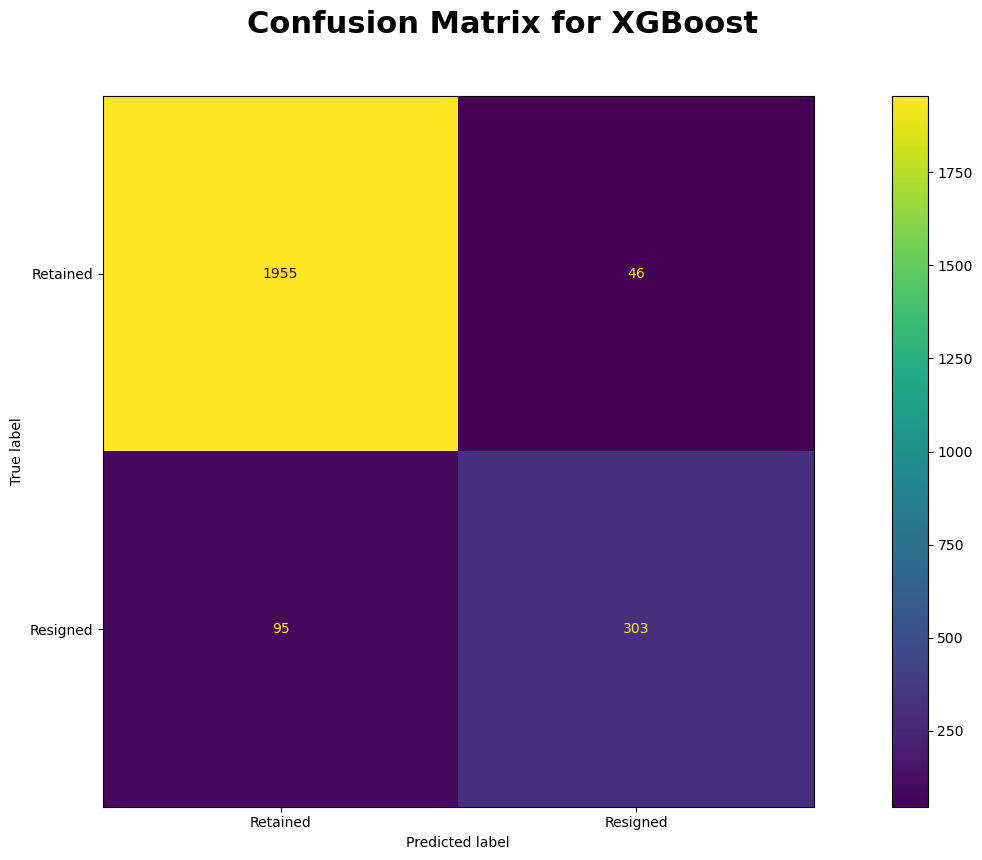

In [41]:
cm = confusion_matrix(y_test, xgb_test_preds, labels=champion.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Retained', 'Resigned'])
fig, ax = plt.subplots(figsize=(16, 9))
disp.plot(ax=ax)
fig.suptitle("Confusion Matrix for XGBoost", fontsize=22, fontweight='bold', x=0.6, horizontalalignment='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- **True Negatives:** 1,955 employees were correctly predicted as retained.
- **False Positives:** 46 employees were incorrectly predicted as resigned.
- **False Negatives:** 95 employees were incorrectly predicted as retained.
- **True Positives:** 303 employees were correctly predicted as resigned.

The model correctly identified 303 of 398 actual resignations, producing a recall of 0.761.

The model also maintained strong precision at 0.868, meaning most employees predicted to resign actually did resign.

### Model Insights

Feature importance was used to identify which variables contributed most to attrition prediction.

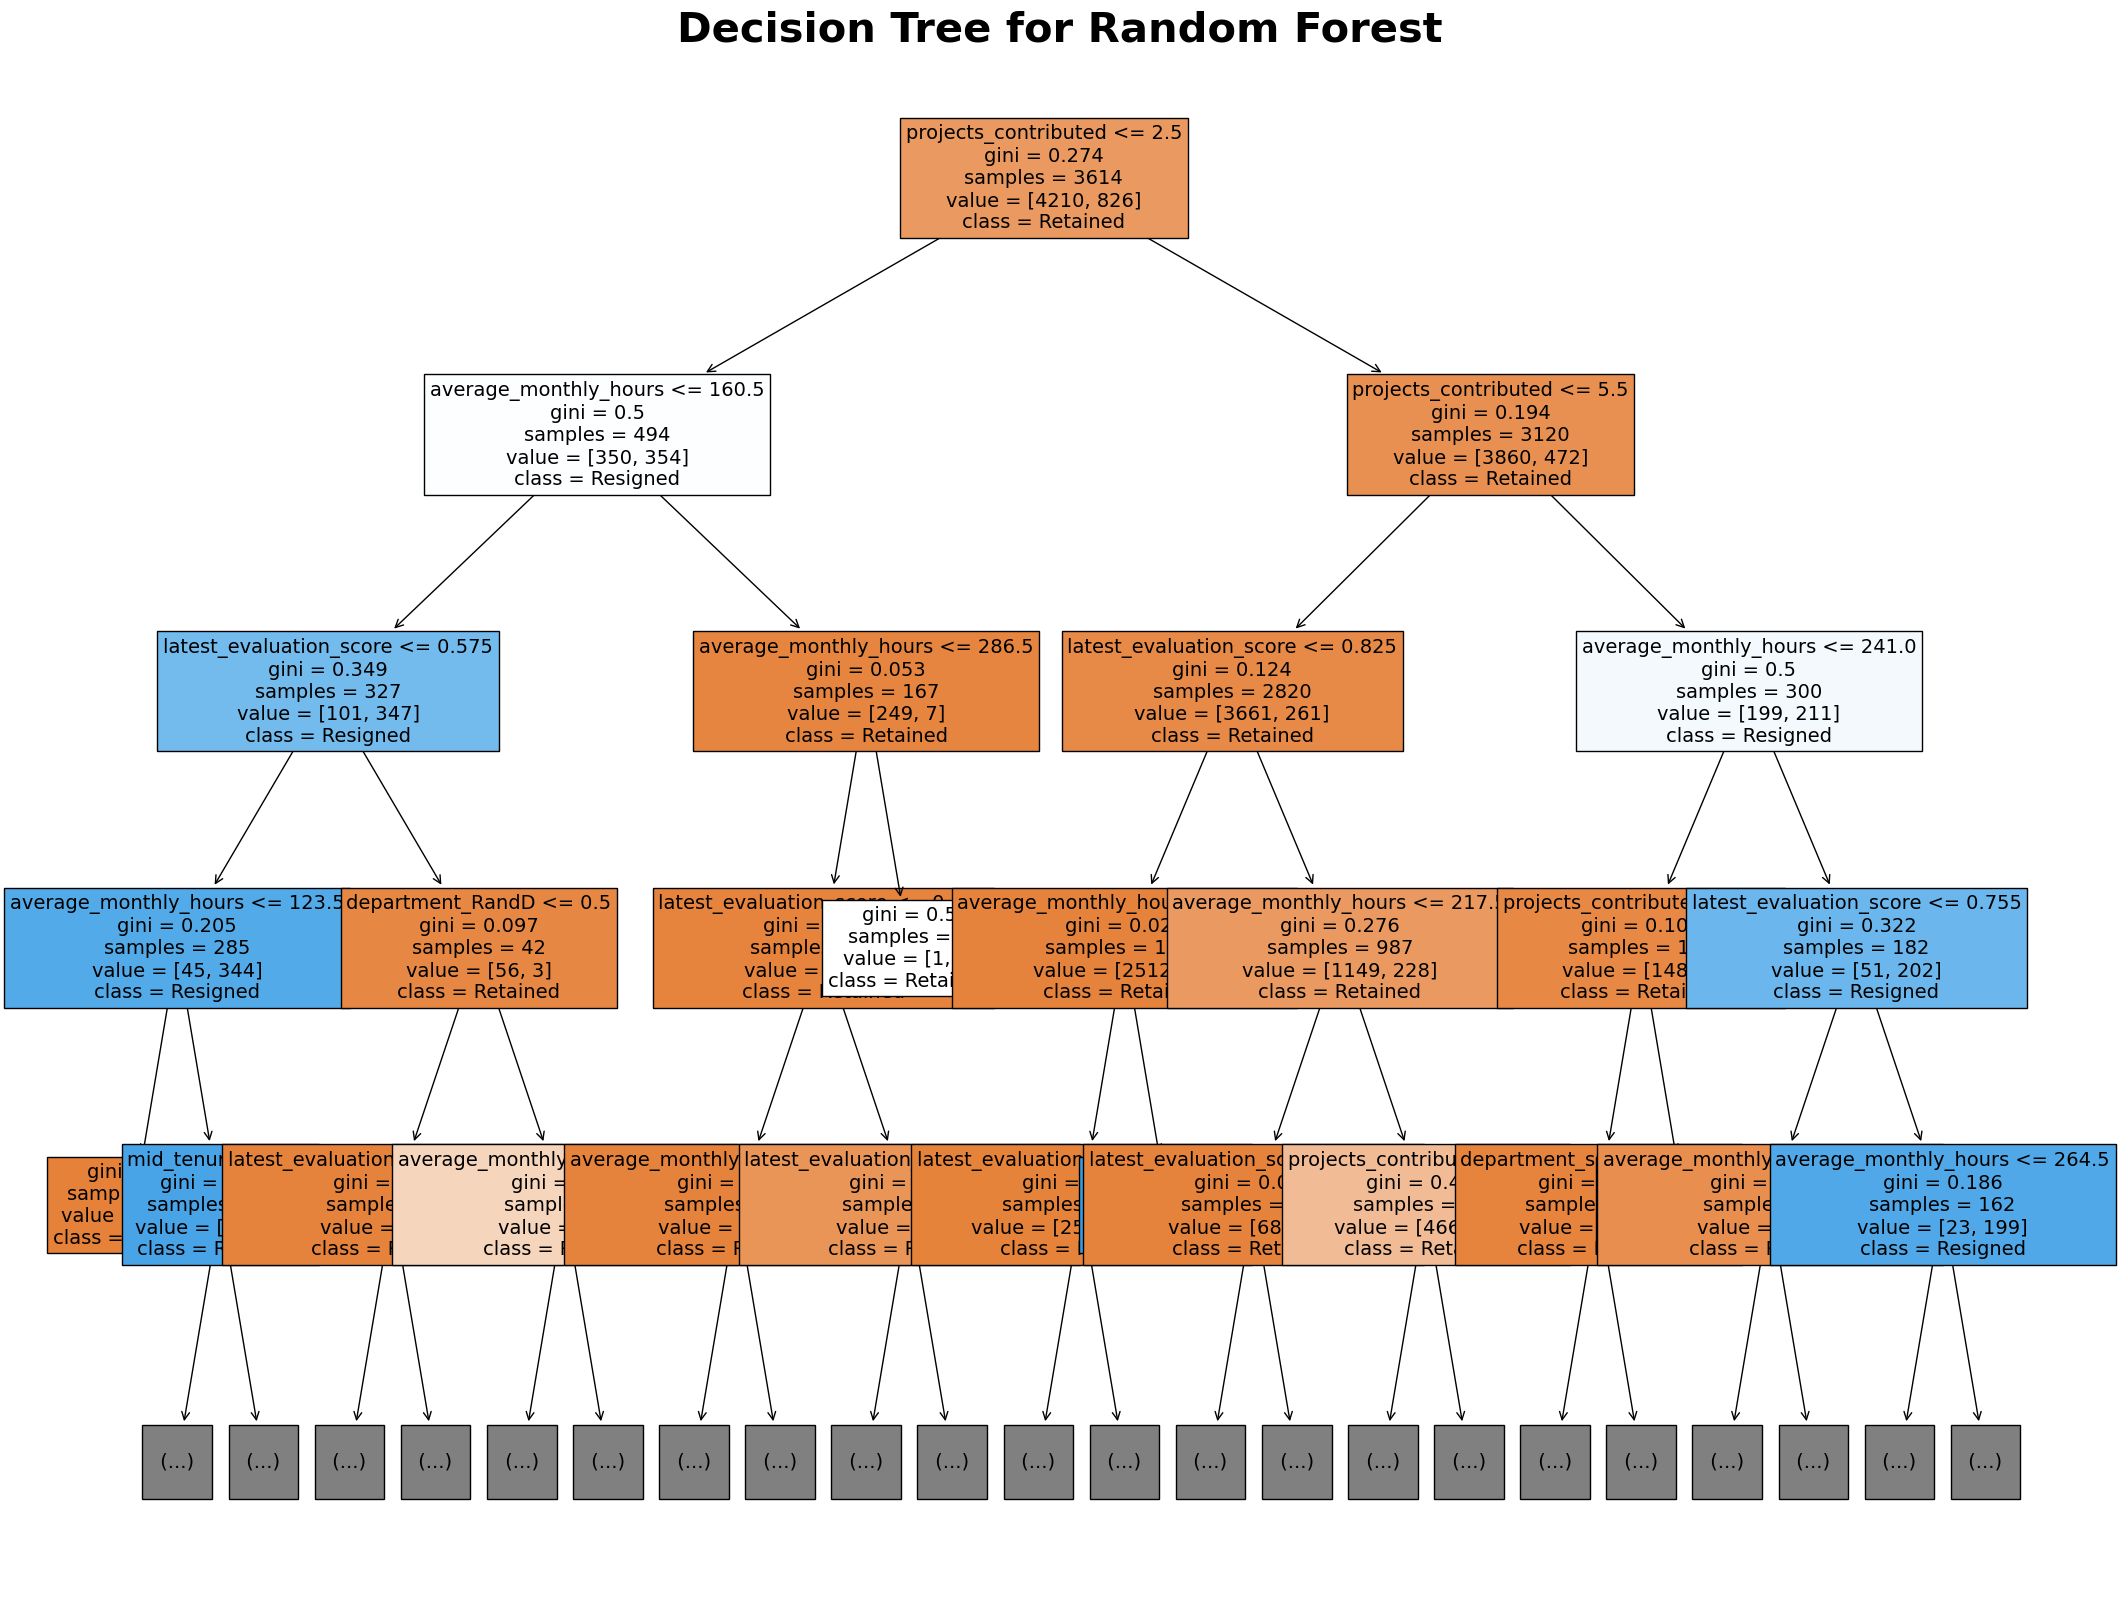

In [42]:
fig, ax = plt.subplots(figsize=(25, 20))
plot_tree(rf_model[0], max_depth=4, fontsize=14, feature_names=X.columns,class_names={0:'Retained', 1:'Resigned'}, filled=True)

ax.set_title("Decision Tree for Random Forest", fontsize=30, fontweight='bold')
plt.show()

The Random Forest tree highlights `projects_contributed`, `average_monthly_hours`, `latest_evaluation_score`, and `mid_tenure` as important splitting variables.

These features align with the EDA findings around workload, performance, and mid-tenure attrition risk.

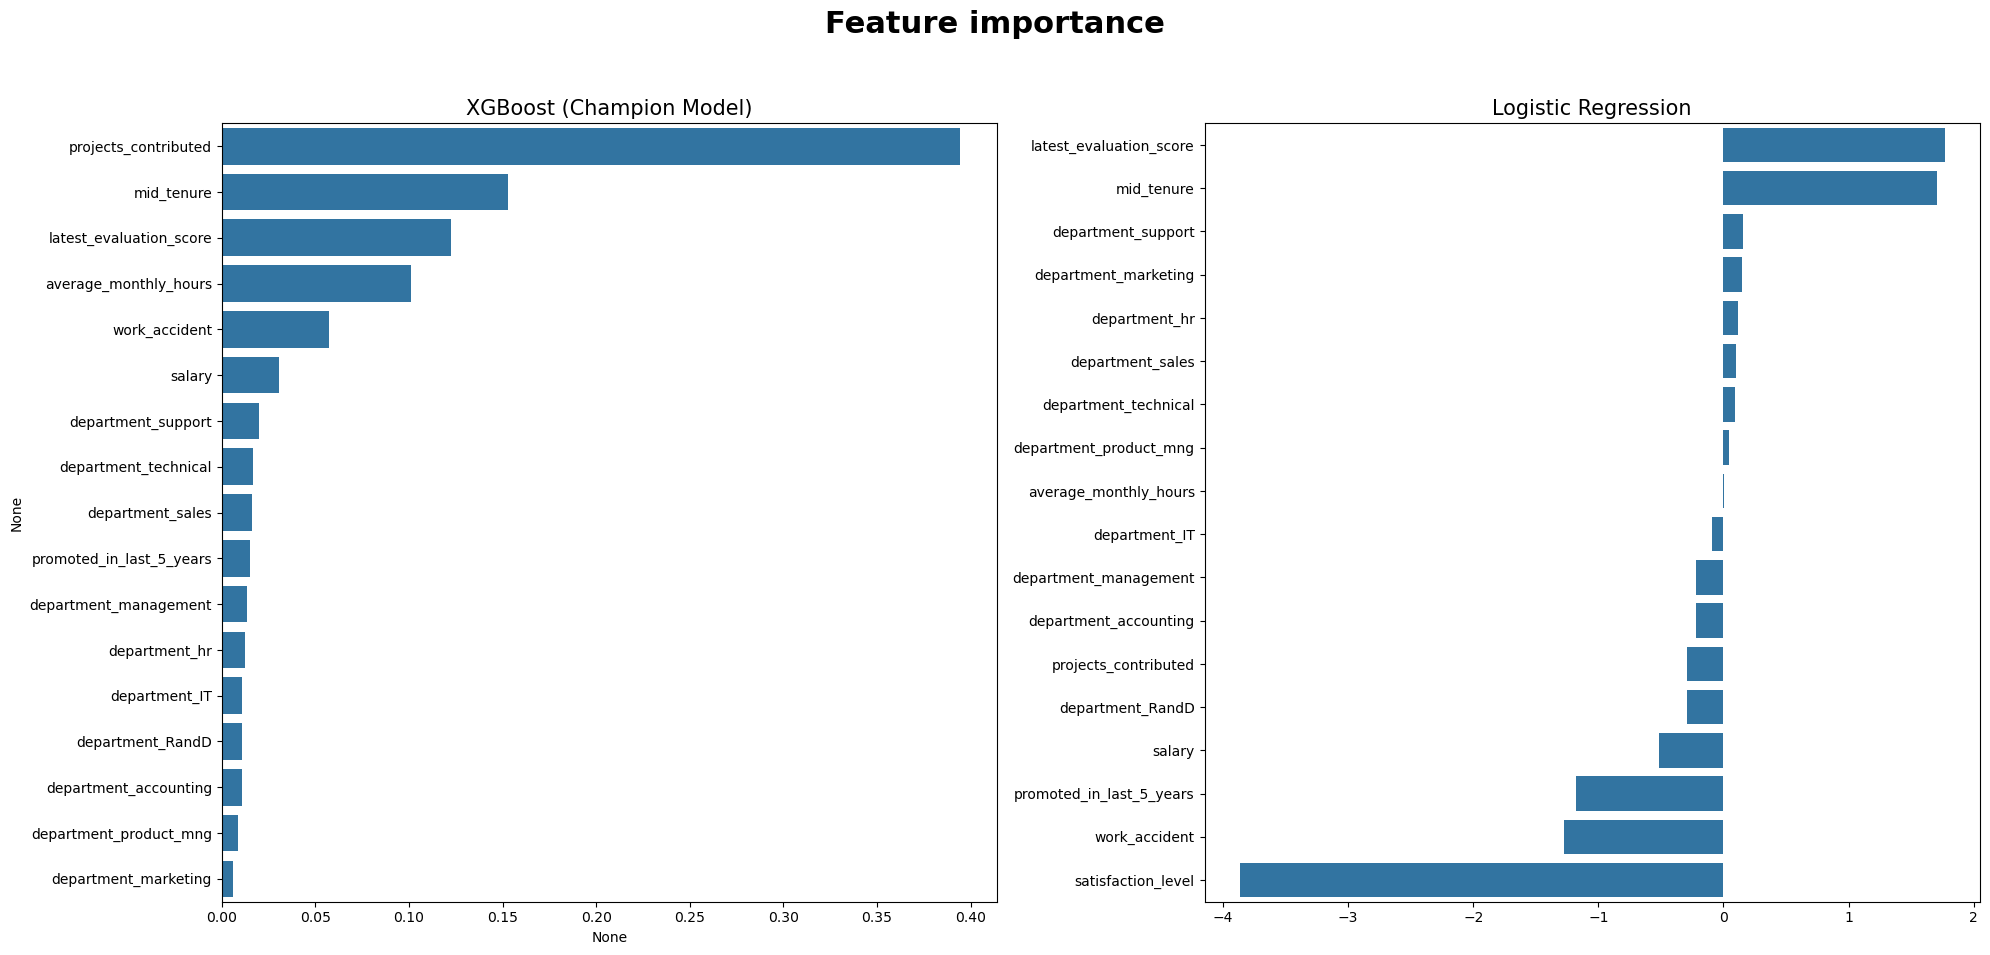

In [43]:
fig, ax = plt.subplots(1,2,figsize=(20, 10))

#Plot 1: Feature importance for XGBoost (Champion model)
importances = champion.feature_importances_
xgb_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

sns.barplot(x=xgb_importance,
            y=xgb_importance.index,
            orient='h', ax=ax[0])

ax[0].set_title('XGBoost (Champion Model)',fontsize=15)

#Plot 2: Feature importance for Logistic Regression

feature_importance = list(zip(X_train_log.columns, clf.coef_[0]))

feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h', ax=ax[1])

ax[1].set_title('Logistic Regression',fontsize=15)

fig.suptitle('Feature importance',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The XGBoost champion model identifies the strongest predictors of attrition as:

- `projects_contributed`
- `mid_tenure`
- `latest_evaluation_score`
- `average_monthly_hours`

These results support two main attrition patterns:

1. **High-performing workload risk:** Employees with more projects, higher evaluation scores, and higher monthly hours show increased attrition risk.
2. **Mid-tenure risk:** Employees in the 3–5 year range appear especially vulnerable to leaving.

Together, the modeling results reinforce the EDA finding that attrition is not only driven by low satisfaction, but also by workload intensity and career-stage risk.

## Section 4: Conclusion and Recommendations 

### Summary 

This project analyzed employee attrition using exploratory data analysis, statistical testing, and machine learning models. 

The dataset shows that 83.4% of employees were retained and 16.6% resigned. Employees who resigned generally showed lower satisfaction, higher workloads, more project involvement, and stronger mid-tenure concentration. 

The final XGBoost model achieved: 
- Accuracy: 94.1% 
- Precision: 0.868 
- Recall: 0.761 
- F1 score: 0.811 

Overall, the results suggest that attrition at this company is strongly associated with workload pressure, high performance demands, and mid-tenure retention risk.